# BlueStock Mutual Fund Analysis

# Day 4 – Performance Analytics

## Objectives

This notebook evaluates the performance of 40 mutual fund schemes using various financial performance metrics.

The analysis includes:

- Daily Returns
- CAGR (1Y, 3Y, 5Y)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison
- Tracking Error

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [4]:
print("NAV Dataset")

print(nav.shape)

print(nav.head())

print("Performance Dataset")

print(performance.shape)

print("Benchmark Dataset")

print(benchmark.shape)

print("Fund Master Dataset")

print(fund_master.shape)

NAV Dataset
(46000, 3)
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
Performance Dataset
(40, 19)
Benchmark Dataset
(8050, 3)
Fund Master Dataset
(40, 15)


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nav = nav.sort_values(
    ["amfi_code","date"]
)

benchmark = benchmark.sort_values(
    "date"
)

# Daily Return Analysis

The first performance metric is Daily Return.

Formula

Daily Return = (Today's NAV / Yesterday's NAV) − 1

In [6]:
nav["daily_return"] = (
    nav
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [7]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

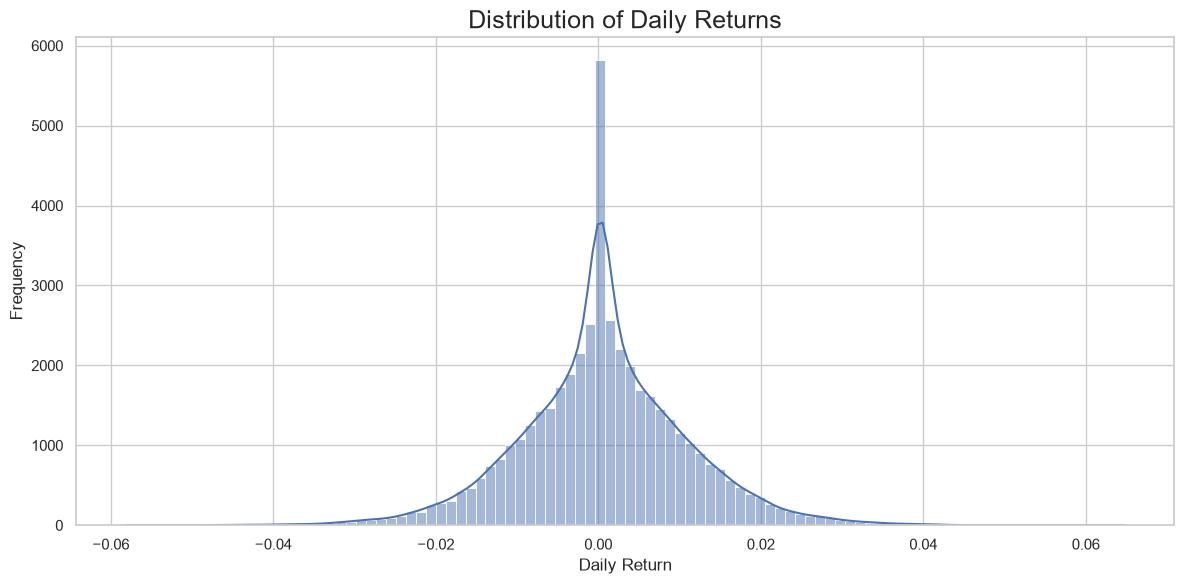

In [8]:
plt.figure(figsize=(12,6))

sns.histplot(
    nav["daily_return"],
    bins=100,
    kde=True
)

plt.title(
    "Distribution of Daily Returns",
    fontsize=18
)

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

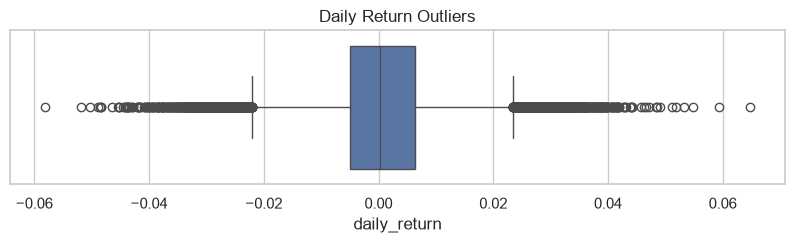

In [9]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=nav["daily_return"]
)

plt.title("Daily Return Outliers")

plt.show()

In [10]:
nav.to_csv(
    "../data/processed/daily_returns.csv",
    index=False
)

print("Daily Returns saved successfully!")

Daily Returns saved successfully!


## Business Insight 1

The majority of daily mutual fund returns are concentrated around zero, indicating relatively stable day-to-day price movements.

Extreme positive and negative returns occur infrequently, reflecting normal market volatility.

# 2. CAGR (Compound Annual Growth Rate)

## Objective

Compound Annual Growth Rate (CAGR) measures the annualized return of a mutual fund over a specified investment period.

This section calculates:

- 1-Year CAGR
- 3-Year CAGR
- 5-Year CAGR

for all 40 mutual fund schemes.

In [11]:
def calculate_cagr(group, years):

    latest_date = group["date"].max()

    start_date = latest_date - pd.DateOffset(years=years)

    period_data = group[group["date"] >= start_date]

    if len(period_data) < 2:
        return np.nan

    start_nav = period_data.iloc[0]["nav"]
    end_nav = period_data.iloc[-1]["nav"]

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    return round(cagr, 2)

In [12]:
cagr_results = []

for fund, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    cagr_results.append({

        "amfi_code": fund,

        "CAGR_1Y (%)": calculate_cagr(group, 1),

        "CAGR_3Y (%)": calculate_cagr(group, 3),

        "CAGR_5Y (%)": calculate_cagr(group, 5)

    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,CAGR_1Y (%),CAGR_3Y (%),CAGR_5Y (%)
0,100016,-2.22,1.29,2.32
1,100025,3.70,3.92,3.91
2,100033,53.23,32.44,26.07
3,101206,47.92,28.97,20.44
4,101207,-23.99,-4.15,6.95


In [13]:
cagr_df = cagr_df.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

cagr_df.head()

,amfi_code,CAGR_1Y (%),CAGR_3Y (%),CAGR_5Y (%),scheme_name
0,100016,-2.22,1.29,2.32,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,3.70,3.92,3.91,HDFC Short Term Debt Fund - Regular - Growth
2,100033,53.23,32.44,26.07,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,47.92,28.97,20.44,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-23.99,-4.15,6.95,ABSL Small Cap Fund - Regular - Growth


In [14]:
cagr_df = cagr_df.sort_values(
    "CAGR_3Y (%)",
    ascending=False
)
cagr_df.head(10)

,amfi_code,CAGR_1Y (%),CAGR_3Y (%),CAGR_5Y (%),scheme_name
16,119094,22.26,35.11,24.45,Axis Midcap Fund - Regular - Growth
34,148567,20.36,34.00,26.80,Mirae Asset Large Cap Fund - Regular - Growth
24,120504,13.06,32.49,20.23,ICICI Pru Bluechip Fund - Direct - Growth
2,100033,53.23,32.44,26.07,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,29.60,31.78,28.38,ICICI Pru Midcap Fund - Regular - Growth
19,119551,60.44,30.46,22.38,SBI Bluechip Fund - Regular Plan - Growth
30,120843,26.66,29.58,26.74,Kotak Flexicap Fund - Regular - Growth
36,148569,39.75,29.18,27.63,Mirae Asset Tax Saver Fund - Regular - Growth
3,101206,47.92,28.97,20.44,ABSL Frontline Equity Fund - Regular - Growth
39,149324,65.14,27.00,27.92,DSP Small Cap Fund - Regular - Growth


In [15]:
cagr_df.to_csv(
    "../data/processed/cagr_results.csv",
    index=False
)
print("CAGR results saved successfully!")

CAGR results saved successfully!


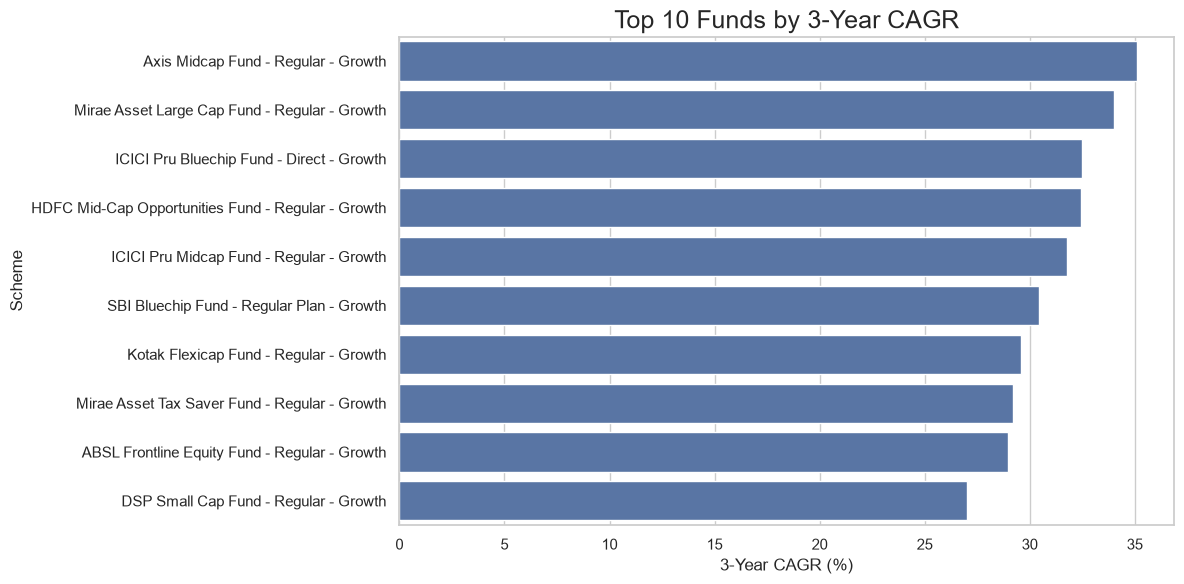

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=cagr_df.head(10),
    x="CAGR_3Y (%)",
    y="scheme_name"
)
plt.title(
    "Top 10 Funds by 3-Year CAGR",
    fontsize=18
)
plt.xlabel("3-Year CAGR (%)")
plt.ylabel("Scheme")
plt.tight_layout()
plt.show()

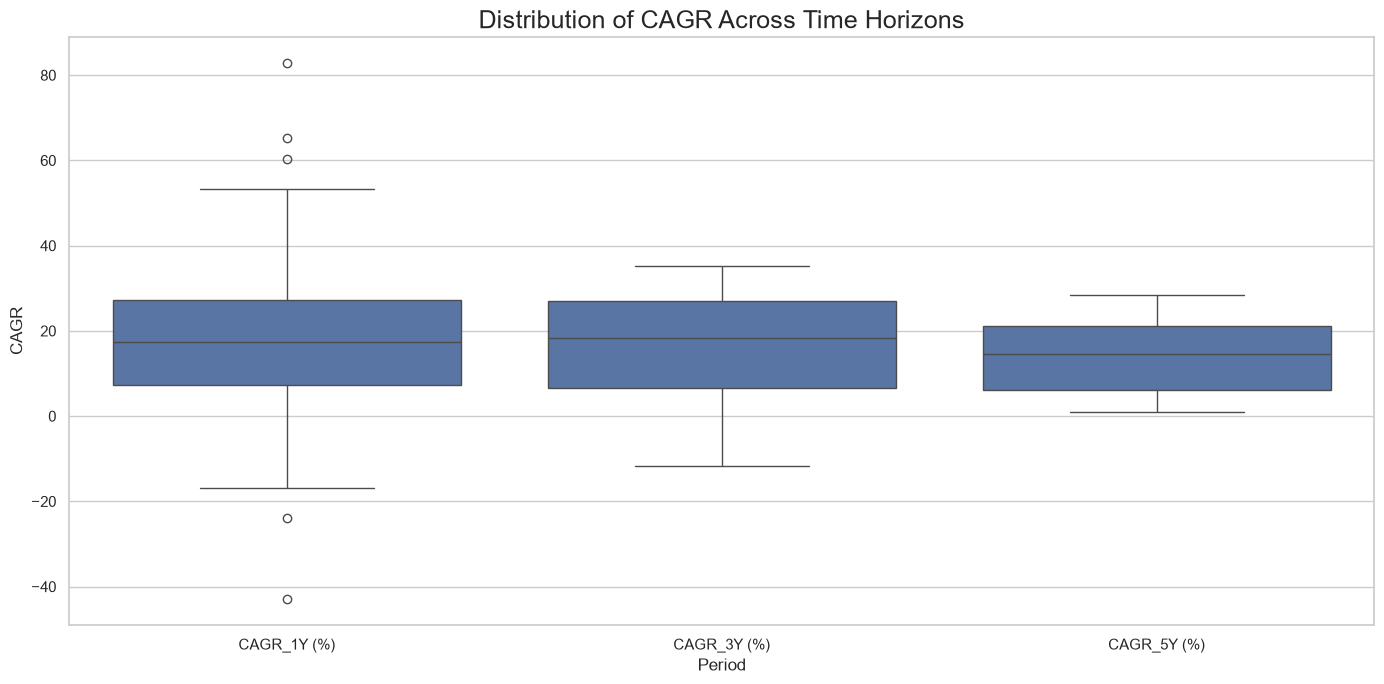

In [17]:
comparison = cagr_df.melt(
    id_vars="scheme_name",
    value_vars=[
        "CAGR_1Y (%)",
        "CAGR_3Y (%)",
        "CAGR_5Y (%)"
    ],
    var_name="Period",
    value_name="CAGR"
)
plt.figure(figsize=(14,7))
sns.boxplot(
    data=comparison,
    x="Period",
    y="CAGR"
)
plt.title(
    "Distribution of CAGR Across Time Horizons",
    fontsize=18
)
plt.tight_layout()
plt.show()

## Business Insight 2

- Funds with consistently high 3-year CAGR indicate strong long-term performance.
- Longer investment horizons generally provide more stable annualized returns.
- CAGR enables investors to compare funds on a standardized annual growth basis.

# 3. Sharpe Ratio Analysis

## Objective

The Sharpe Ratio measures the risk-adjusted return of a mutual fund.
Higher Sharpe Ratio indicates better returns for each unit of risk taken.

Formula:
Sharpe Ratio = (Annual Return − Risk Free Rate) / Annualized Standard Deviation

In [18]:
risk_free_rate = 0.065

In [19]:
sharpe_results = []
for fund, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    if len(returns) > 1:
        annual_return = returns.mean() * 252
        annual_std = returns.std() * np.sqrt(252)
        sharpe = (annual_return - risk_free_rate) / annual_std
        sharpe_results.append({
            "amfi_code": fund,
            "Sharpe Ratio": round(sharpe, 3)
        })
sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df.head()

,amfi_code,Sharpe Ratio
0,100016,-0.202
1,100025,-0.567
2,100033,1.094
3,101206,1.027
4,101207,0.163


In [20]:
sharpe_df = sharpe_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)
sharpe_df.head()

,amfi_code,Sharpe Ratio,scheme_name
0,100016,-0.202,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.094,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.163,ABSL Small Cap Fund - Regular - Growth


In [21]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe Ratio",
    ascending=False
).reset_index(drop=True)
sharpe_df["Rank"] = sharpe_df.index + 1
sharpe_df.head(10)

,amfi_code,Sharpe Ratio,scheme_name,Rank
0,148567,1.448,Mirae Asset Large Cap Fund - Regular - Growth,1
1,120843,1.307,Kotak Flexicap Fund - Regular - Growth,2
2,148569,1.235,Mirae Asset Tax Saver Fund - Regular - Growth,3
3,119551,1.208,SBI Bluechip Fund - Regular Plan - Growth,4
4,120505,1.180,ICICI Pru Midcap Fund - Regular - Growth,5
5,149323,1.132,DSP Midcap Fund - Regular - Growth,6
6,100033,1.094,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7
7,118632,1.082,Nippon India Large Cap Fund - Regular - Growth,8
8,101206,1.027,ABSL Frontline Equity Fund - Regular - Growth,9
9,120504,1.027,ICICI Pru Bluechip Fund - Direct - Growth,10


In [22]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)
print("Sharpe Ratio saved successfully!")

Sharpe Ratio saved successfully!


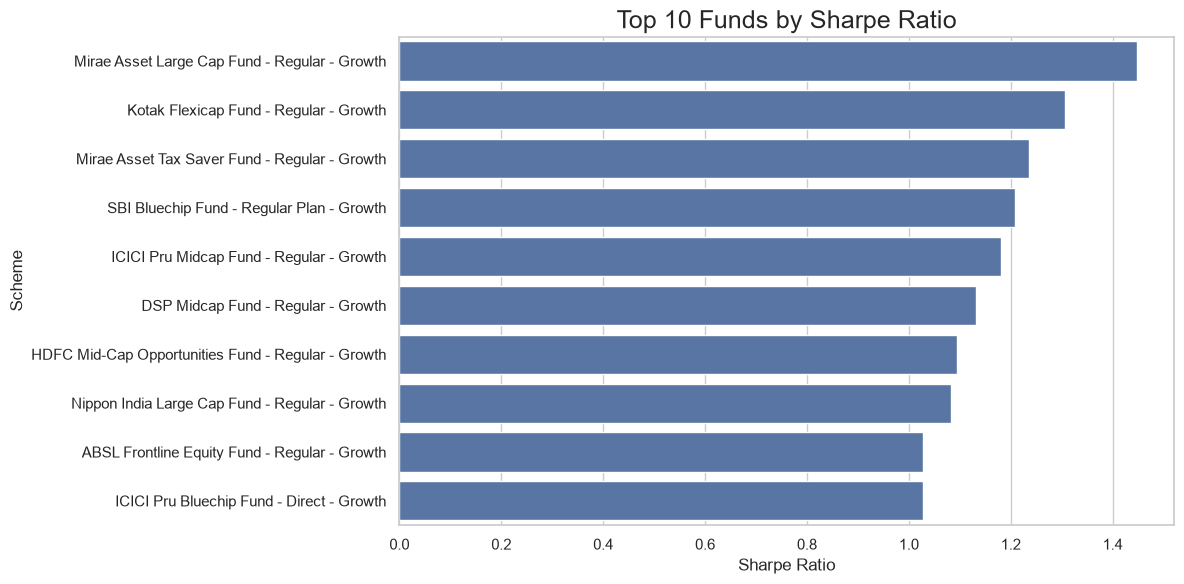

In [23]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=sharpe_df.head(10),
    x="Sharpe Ratio",
    y="scheme_name"
)
plt.title(
    "Top 10 Funds by Sharpe Ratio",
    fontsize=18
)
plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme")
plt.tight_layout()
plt.show()

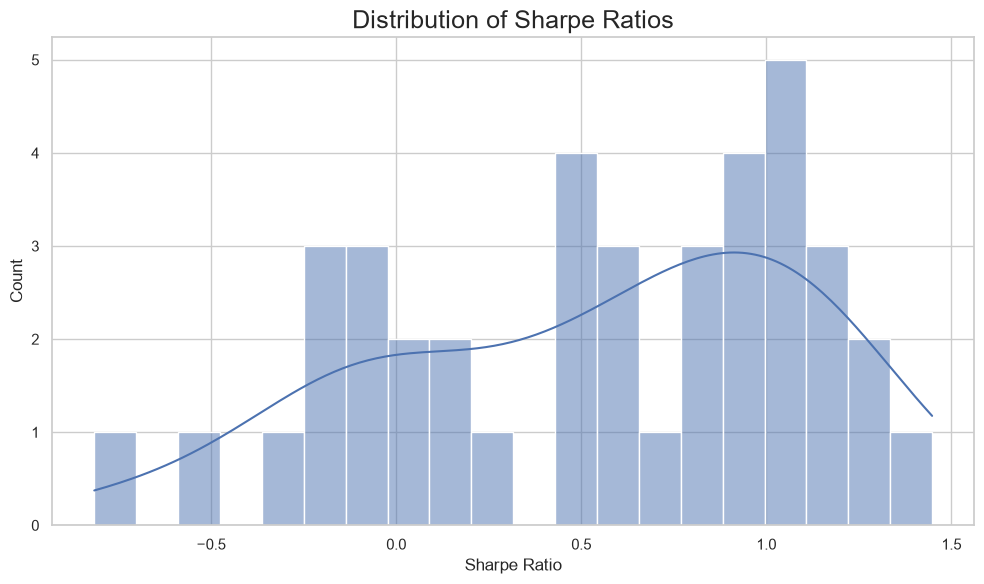

In [24]:
plt.figure(figsize=(10,6))
sns.histplot(
    sharpe_df["Sharpe Ratio"],
    bins=20,
    kde=True
)
plt.title(
    "Distribution of Sharpe Ratios",
    fontsize=18
)
plt.xlabel("Sharpe Ratio")
plt.tight_layout()
plt.show()

## Business Insight 3

- Funds with higher Sharpe Ratios generated better risk-adjusted returns.
- A higher Sharpe Ratio indicates efficient portfolio management.
- Investors should compare funds using risk-adjusted metrics rather than returns alone.

# 4. Sortino Ratio Analysis

## Objective

The Sortino Ratio measures risk-adjusted performance by considering only downside risk.
Unlike the Sharpe Ratio, it ignores positive volatility and focuses only on negative return days.
Formula:

Sortino Ratio = (Annual Return − Risk Free Rate) / Downside Standard Deviation

In [25]:
risk_free_rate = 0.065

sortino_results = []

for fund, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    downside_returns = returns[returns < 0]
    if len(downside_returns) > 1:
        annual_return = returns.mean() * 252
        downside_std = downside_returns.std() * np.sqrt(252)
        sortino = (
            annual_return - risk_free_rate
        ) / downside_std
        sortino_results.append({
            "amfi_code": fund,
            "Sortino Ratio": round(sortino,3)
        })
sortino_df = pd.DataFrame(sortino_results)
sortino_df.head()

,amfi_code,Sortino Ratio
0,100016,-0.351
1,100025,-0.942
2,100033,1.829
3,101206,1.800
4,101207,0.277


In [26]:
sortino_df = sortino_df.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

sortino_df.head()

,amfi_code,Sortino Ratio,scheme_name
0,100016,-0.351,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.942,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.800,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.277,ABSL Small Cap Fund - Regular - Growth


In [27]:
sortino_df = sortino_df.sort_values(
    "Sortino Ratio",
    ascending=False
).reset_index(drop=True)
sortino_df["Rank"] = sortino_df.index + 1
sortino_df.head(10)

,amfi_code,Sortino Ratio,scheme_name,Rank
0,148567,2.386,Mirae Asset Large Cap Fund - Regular - Growth,1
1,120843,2.364,Kotak Flexicap Fund - Regular - Growth,2
2,148569,2.147,Mirae Asset Tax Saver Fund - Regular - Growth,3
3,119551,2.140,SBI Bluechip Fund - Regular Plan - Growth,4
4,120505,2.029,ICICI Pru Midcap Fund - Regular - Growth,5
5,149323,1.875,DSP Midcap Fund - Regular - Growth,6
6,118632,1.850,Nippon India Large Cap Fund - Regular - Growth,7
7,100033,1.829,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,8
8,120504,1.805,ICICI Pru Bluechip Fund - Direct - Growth,9
9,101206,1.800,ABSL Frontline Equity Fund - Regular - Growth,10


In [28]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)
print("Sortino Ratio saved successfully!")

Sortino Ratio saved successfully!


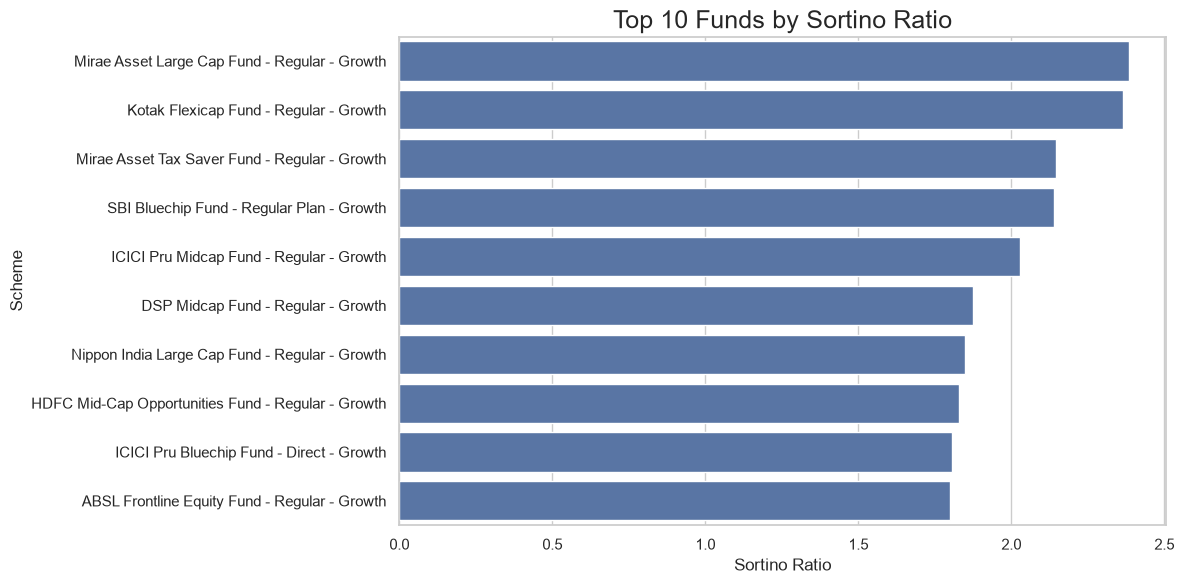

In [29]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=sortino_df.head(10),
    x="Sortino Ratio",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds by Sortino Ratio",
    fontsize=18
)

plt.xlabel("Sortino Ratio")
plt.ylabel("Scheme")
plt.tight_layout()
plt.show()

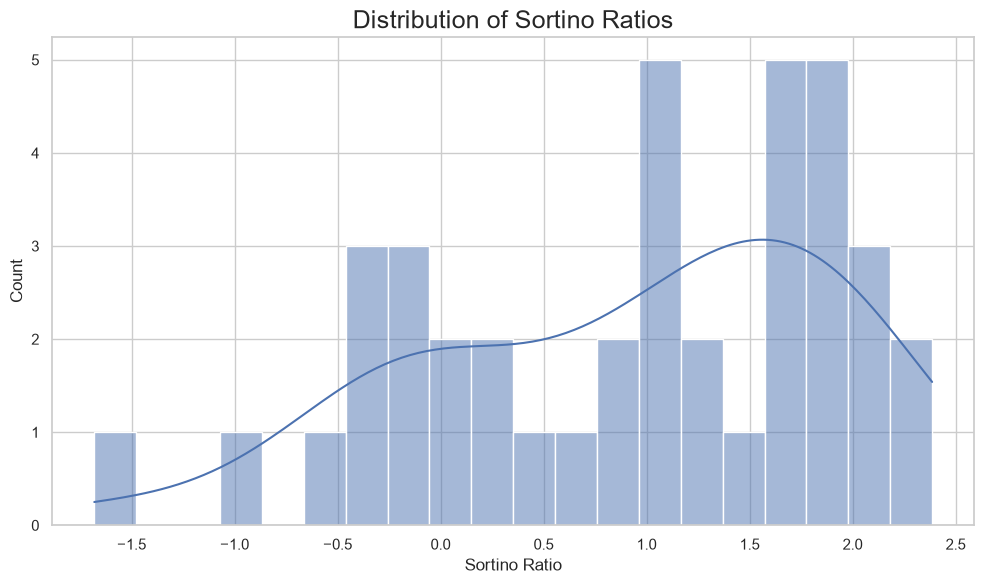

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(
    sortino_df["Sortino Ratio"],
    bins=20,
    kde=True
)

plt.title(
    "Distribution of Sortino Ratios",
    fontsize=18
)

plt.xlabel("Sortino Ratio")
plt.tight_layout()
plt.show()

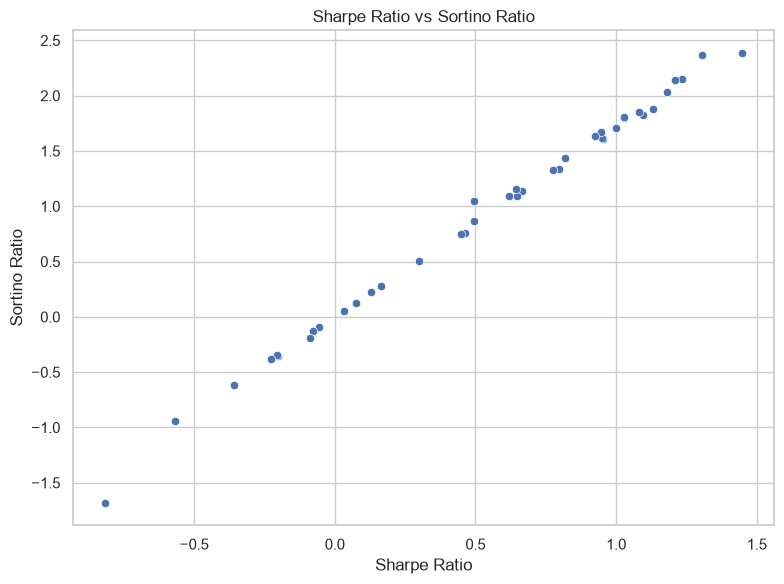

In [31]:
comparison = sharpe_df.merge(
    sortino_df,
    on=["amfi_code","scheme_name"]
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=comparison,
    x="Sharpe Ratio",
    y="Sortino Ratio"
)

plt.title("Sharpe Ratio vs Sortino Ratio")
plt.tight_layout()
plt.show()

## Business Insight 4

- Funds with high Sortino Ratios generated superior returns while effectively limiting downside risk.
- Comparing Sharpe and Sortino Ratios provides a more complete assessment of risk-adjusted performance.
- Investors who prioritize capital preservation should focus on funds with higher Sortino Ratios.

# 5. Alpha & Beta Analysis

## Objective

Alpha and Beta measure the relationship between mutual fund returns and the benchmark (Nifty 100).

- Beta measures market sensitivity.
- Alpha measures excess return generated by the fund after adjusting for market risk.

The calculations use Ordinary Least Squares (OLS) regression through scipy.stats.linregress.

In [32]:
# Select NIFTY100 benchmark
benchmark_nifty = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

benchmark_nifty["benchmark_return"] = (
    benchmark_nifty["close_value"]
    .pct_change()
)

benchmark_nifty = benchmark_nifty[
    ["date", "benchmark_return"]
]

benchmark_nifty.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [33]:
alpha_beta_results = []
for fund, group in nav.groupby("amfi_code"):
    merged = pd.merge(
        group,
        benchmark_nifty,
        on="date",
        how="inner"
    ).dropna()
    if len(merged) < 30:
        continue
    slope, intercept, r, p, std = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": fund,
        "Alpha": round(intercept * 252, 4),
        "Beta": round(slope, 4),
        "R_Squared": round(r**2, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared
0,100016,0.0375,-0.0583,0.0027
1,100025,0.0428,0.0012,0.0000
2,100033,0.2720,0.0051,0.0000
3,101206,0.2140,0.0211,0.0003
4,101207,0.1090,-0.0653,0.0011


In [34]:
alpha_beta_df = alpha_beta_df.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared,scheme_name
0,100016,0.0375,-0.0583,0.0027,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.0428,0.0012,0.0000,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.2720,0.0051,0.0000,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.2140,0.0211,0.0003,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.1090,-0.0653,0.0011,ABSL Small Cap Fund - Regular - Growth


In [35]:
alpha_beta_df.to_csv(

    "../data/processed/alpha_beta.csv",
    index=False
)
print("Alpha & Beta results saved successfully!")

Alpha & Beta results saved successfully!


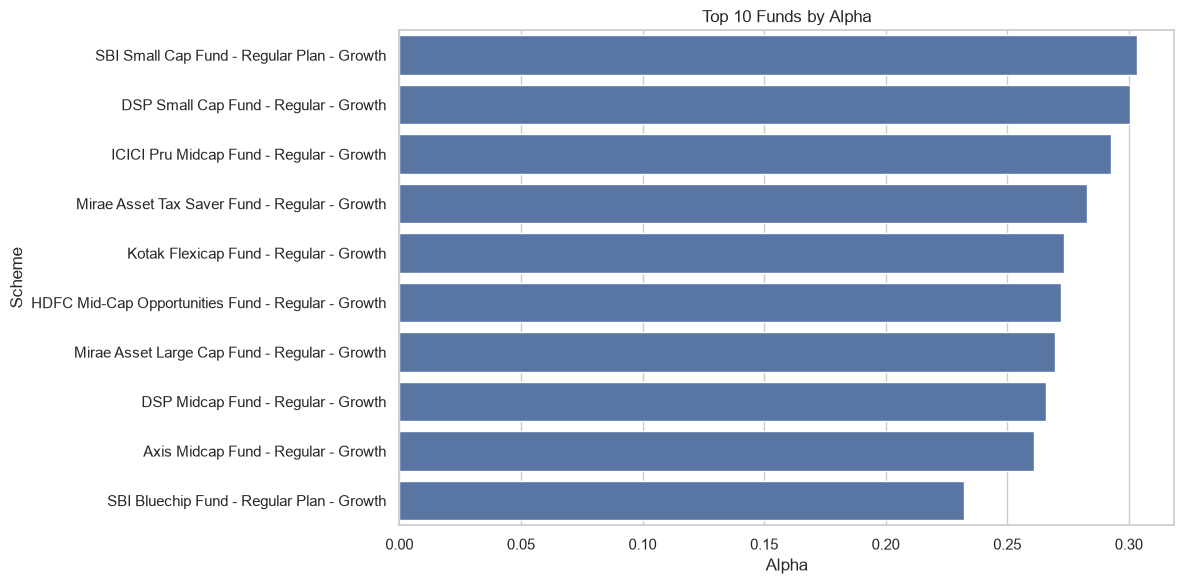

In [36]:
top_alpha = alpha_beta_df.sort_values(

    "Alpha",
    ascending=False
).head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_alpha,
    x="Alpha",
    y="scheme_name"
)
plt.title("Top 10 Funds by Alpha")
plt.xlabel("Alpha")
plt.ylabel("Scheme")
plt.tight_layout()
plt.show()

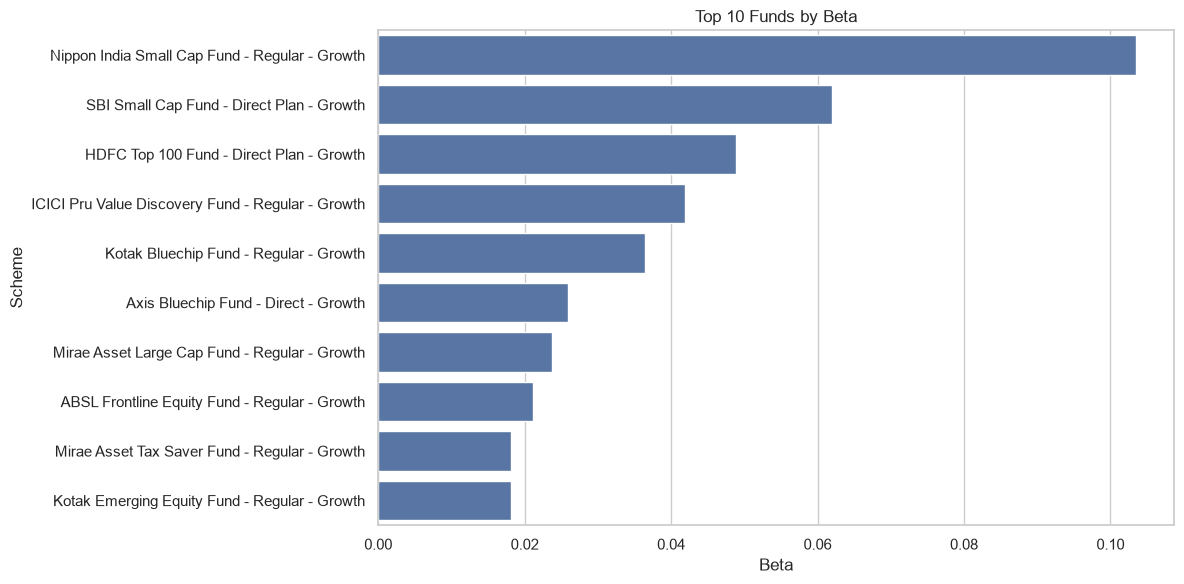

In [37]:
top_beta = alpha_beta_df.sort_values(
    "Beta",
    ascending=False
).head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_beta,
    x="Beta",
    y="scheme_name"
)

plt.title("Top 10 Funds by Beta")
plt.xlabel("Beta")
plt.ylabel("Scheme")
plt.tight_layout()
plt.show()

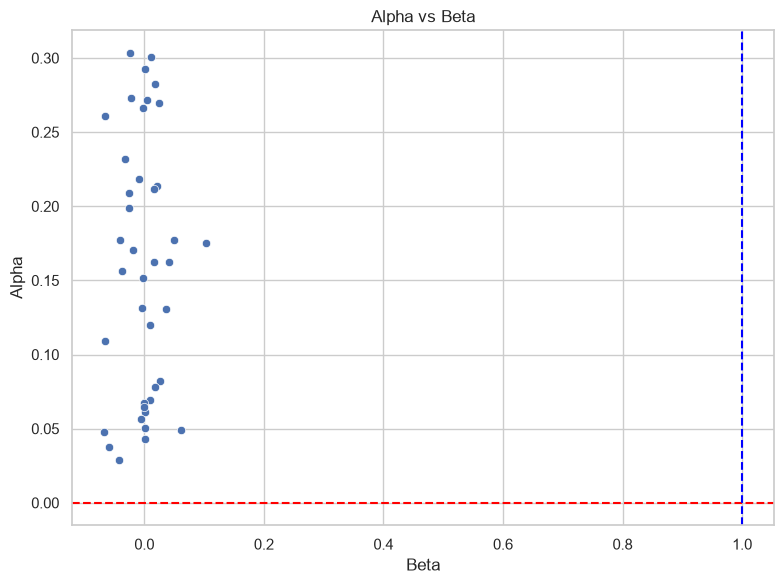

In [38]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=alpha_beta_df,
    x="Beta",
    y="Alpha"
)

plt.axhline(0, color="red", linestyle="--")
plt.axvline(1, color="blue", linestyle="--")
plt.title("Alpha vs Beta")
plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.tight_layout()
plt.show()

## Business Insight 5

- Funds with positive Alpha generated returns above market expectations.
- Beta values close to 1 indicate that fund performance closely follows the Nifty 100 benchmark.
- High Alpha combined with moderate Beta represents an attractive risk-return profile.

# 6. Maximum Drawdown Analysis

## Objective

Maximum Drawdown (MDD) measures the largest percentage decline from a fund's peak NAV to its subsequent lowest point.

Lower drawdowns generally indicate lower downside risk.

In [39]:
mdd_results = []

for fund, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    # Worst drawdown
    max_drawdown = group["drawdown"].min()

    # Date of worst drawdown
    worst_date = group.loc[
        group["drawdown"].idxmin(),
        "date"
    ]

    mdd_results.append({

        "amfi_code": fund,

        "Maximum Drawdown": round(max_drawdown,4),

        "Worst Drawdown Date": worst_date

    })

mdd_df = pd.DataFrame(mdd_results)

mdd_df.head()

,amfi_code,Maximum Drawdown,Worst Drawdown Date
0,100016,-0.2473,2022-09-15
1,100025,-0.0431,2023-07-28
2,100033,-0.1622,2022-05-12
3,101206,-0.1129,2023-07-05
4,101207,-0.3545,2026-05-11


In [40]:
mdd_df = mdd_df.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)
mdd_df.head()

,amfi_code,Maximum Drawdown,Worst Drawdown Date,scheme_name
0,100016,-0.2473,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.0431,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.1622,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.1129,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.3545,2026-05-11,ABSL Small Cap Fund - Regular - Growth


In [41]:
mdd_df.to_csv(
    "../data/processed/maximum_drawdown.csv",
    index=False
)
print("Maximum Drawdown saved successfully!")

Maximum Drawdown saved successfully!


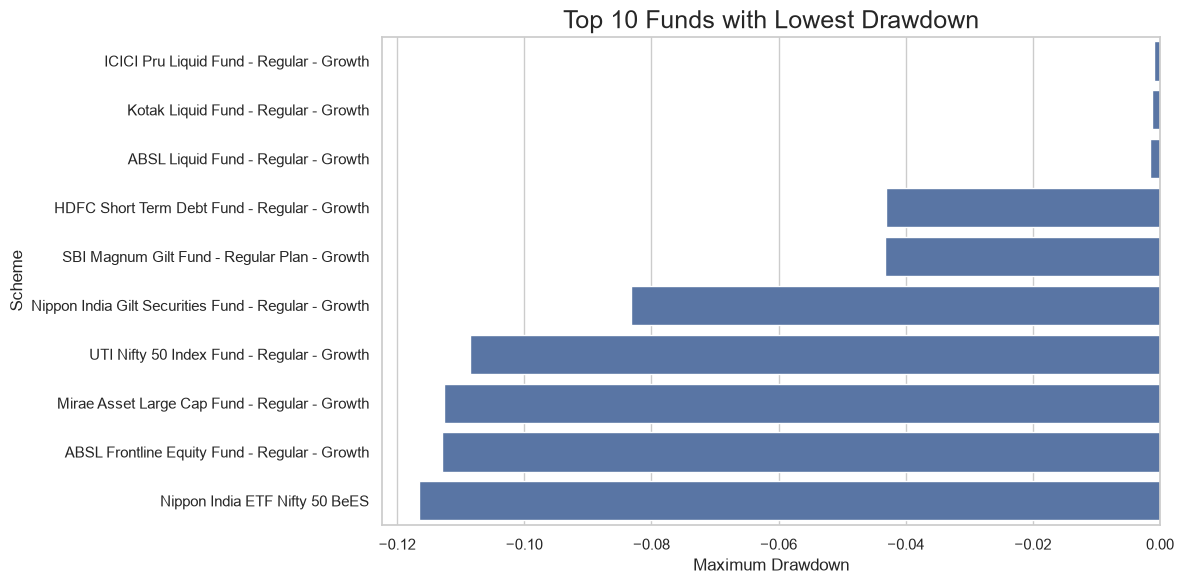

In [42]:
best_drawdown = mdd_df.sort_values(

    "Maximum Drawdown",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=best_drawdown,
    x="Maximum Drawdown",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds with Lowest Drawdown",
    fontsize=18
)

plt.xlabel("Maximum Drawdown")
plt.ylabel("Scheme")
plt.tight_layout()
plt.show()

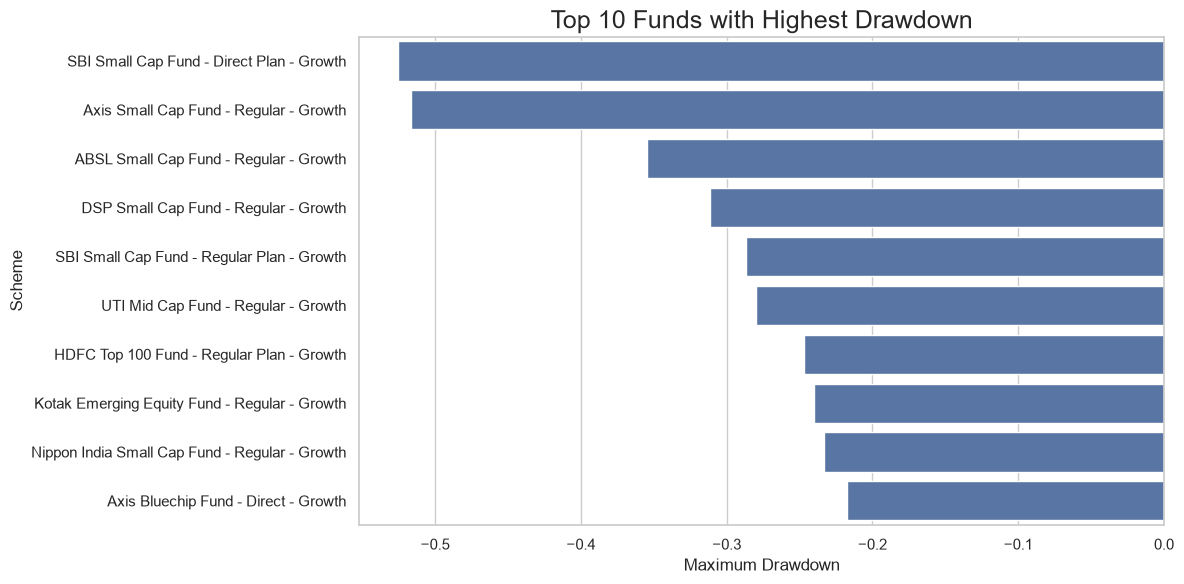

In [43]:
worst_drawdown = mdd_df.sort_values(
    "Maximum Drawdown"
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_drawdown,
    x="Maximum Drawdown",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds with Highest Drawdown",
    fontsize=18
)

plt.xlabel("Maximum Drawdown")
plt.ylabel("Scheme")
plt.tight_layout()
plt.show()

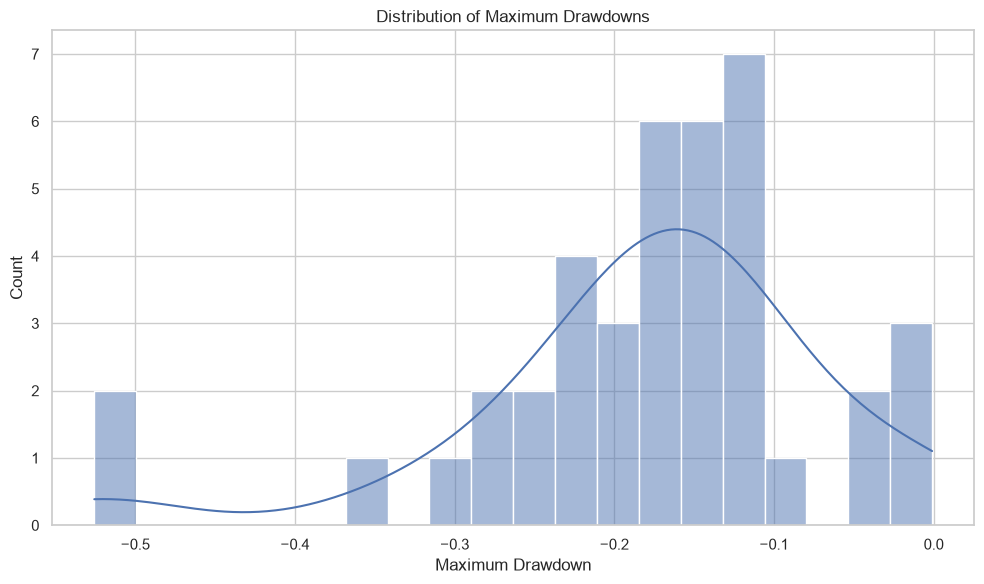

In [44]:
plt.figure(figsize=(10,6))

sns.histplot(
    mdd_df["Maximum Drawdown"],
    bins=20,
    kde=True
)

plt.title("Distribution of Maximum Drawdowns")
plt.xlabel("Maximum Drawdown")
plt.tight_layout()
plt.show()

## Business Insight 6

- Funds with lower maximum drawdowns demonstrated better downside protection during adverse market conditions.
- Investors seeking lower risk may prefer funds with smaller historical drawdowns.
- Maximum Drawdown complements Sharpe and Sortino Ratios by focusing on capital preservation.

# 7. Fund Performance Scorecard

## Objective

This section combines multiple performance metrics into a single composite score.

The scorecard evaluates each mutual fund using:

- 3-Year CAGR
- Sharpe Ratio
- Alpha
- Expense Ratio
- Maximum Drawdown

Lower scores indicate better overall performance.

In [45]:
performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
sharpe = pd.read_csv("../data/processed/sharpe_ratio.csv")
alpha = pd.read_csv("../data/processed/alpha_beta.csv")
mdd = pd.read_csv("../data/processed/maximum_drawdown.csv")
cagr = pd.read_csv("../data/processed/cagr_results.csv")

In [46]:
scorecard = performance.merge(
    cagr[
        ["amfi_code","CAGR_3Y (%)"]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    sharpe[
        ["amfi_code","Sharpe Ratio"]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha[
        ["amfi_code","Alpha"]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    mdd[
        ["amfi_code","Maximum Drawdown"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,CAGR_3Y (%),Sharpe Ratio,Alpha,Maximum Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,14.0,-21.70,14288,1.54,4,Moderate,30.46,1.208,0.2320,-0.1501
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,14.0,-24.43,1231,0.66,3,Moderate,16.27,0.953,0.1987,-0.1180
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,25.0,-13.35,19259,1.43,5,Very High,26.67,0.945,0.3034,-0.2871
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,25.0,-24.78,36061,0.72,4,Very High,-1.34,-0.057,0.0488,-0.5257
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,4.0,-2.30,24101,0.77,5,Low,5.84,-0.227,0.0562,-0.0433


In [47]:
scorecard["return_rank"] = scorecard["CAGR_3Y (%)"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["Alpha"].rank(ascending=False)
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["drawdown_rank"] = scorecard["Maximum Drawdown"].rank(ascending=False)